In [406]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy.stats import kendalltau

transac_cost = 0.001

In [407]:
px = yf.download("^GSPC", start="1980-01-01", end="2023-12-31")['Close']
daily = (px / px.shift(1) -1).dropna()
temp = px.asfreq('D', 'bfill')
monthly = temp[temp.index.day == 1]
monthly = (monthly / monthly.shift(1) -1).dropna()
monthly.columns = ["monthly_ret"]

def get_trading_day_of_month(series):
    trading_day_of_month = []
    count = 0
    month = series.index[0].month
    for i in series.index:
        if i.month != month:
            count = 1
            month = i.month
        else:
            count += 1
        trading_day_of_month.append(count)
    return pd.Series(trading_day_of_month, index=series.index)

trading_daily = pd.concat([daily, get_trading_day_of_month(px)], axis=1).dropna()
trading_daily.columns = ["daily_ret", "trading_day"]

[*********************100%***********************]  1 of 1 completed


In [408]:
print(((1+daily).cumprod().iloc[-1] - 1).values)
print(((1+monthly).cumprod().iloc[-1] - 1).values)
print((px.iloc[-1] / px.iloc[0] -1).values)

[44.10051042]
[38.91165543]
[44.10051042]


## Monthly Seasonality

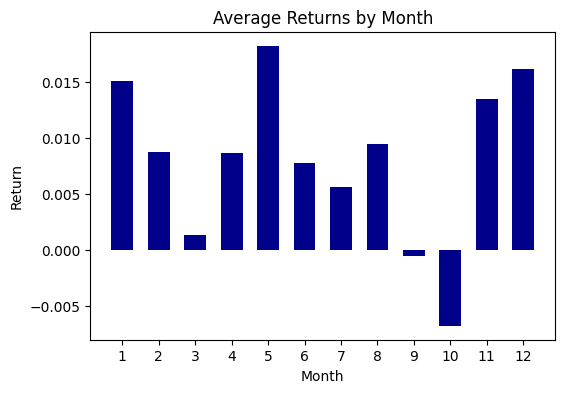

In [409]:
plt.figure(figsize=(6, 4))     
plt.bar(range(1,13), monthly.groupby(monthly.index.month).mean()['monthly_ret'], 
        width = 0.6, color="darkblue")
plt.xticks(range(1, 13))
plt.title("Average Returns by Month")
plt.xlabel("Month")
plt.ylabel("Return")
plt.savefig('Average Returns by Month.png')
plt.show()

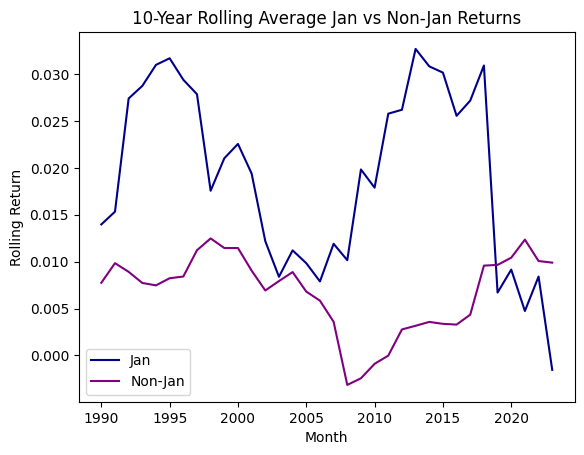

In [410]:
jan_returns = monthly[monthly.index.month == 1]
non_jan_returns = monthly[monthly.index.month != 1]
temp1 = jan_returns.groupby(jan_returns.index.year).mean().rolling(10).mean().dropna()
temp2 = non_jan_returns.groupby(non_jan_returns.index.year).mean().rolling(10).mean().dropna()

plt.plot(range(1990,2024), temp1, color="darkblue")
plt.plot(range(1990,2024), temp2[temp2.index>=1990], color="purple")
plt.title("10-Year Rolling Average Jan vs Non-Jan Returns")
plt.legend(["Jan", "Non-Jan"])
plt.xlabel("Month")
plt.ylabel("Rolling Return")
plt.savefig('10-Year Rolling Average Jan vs Non-Jan Returns.png')
plt.show()

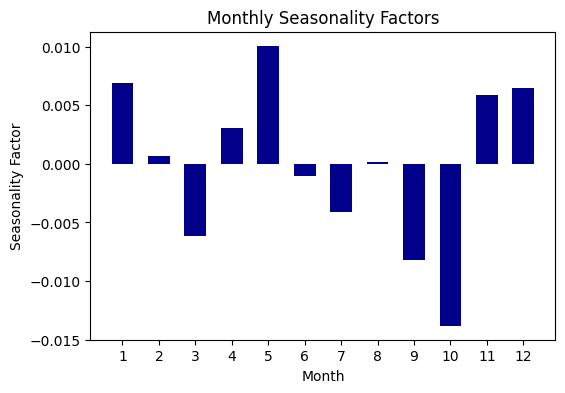

In [411]:
decom = seasonal_decompose(monthly, period=12, two_sided=True)
trend = decom.trend; seasonal = decom.seasonal; residual = decom.resid

plt.figure(figsize=(6, 4))     
plt.bar(range(1,13), seasonal.groupby(seasonal.index.month).mean(), 
        width = 0.6, color="darkblue")
plt.xticks(range(1, 13))
plt.title('Monthly Seasonality Factors')
plt.xlabel('Month')
plt.ylabel('Seasonality Factor')
plt.savefig('Seasonality Factor by Month.png')
plt.show()

In [412]:
def halloween(trading_daily, month_long=[1,2,4,5,11,12], starting_year=1980):
    strategy = trading_daily[trading_daily.index.year >= starting_year].copy()
    strategy["position"] = strategy.index.month.isin(month_long).astype(int)
    strategy["pos_change"] = (strategy["position"] - strategy["position"].shift(1)).fillna(1)
    strategy["port_daily_ret"] = strategy["daily_ret"] * strategy["position"] - transac_cost * abs(strategy["pos_change"])
    strategy["cum_ret"] = (1+strategy["port_daily_ret"]).cumprod()
    strategy["buy_hold_ret"] = (1+strategy["daily_ret"]).cumprod()
    return strategy



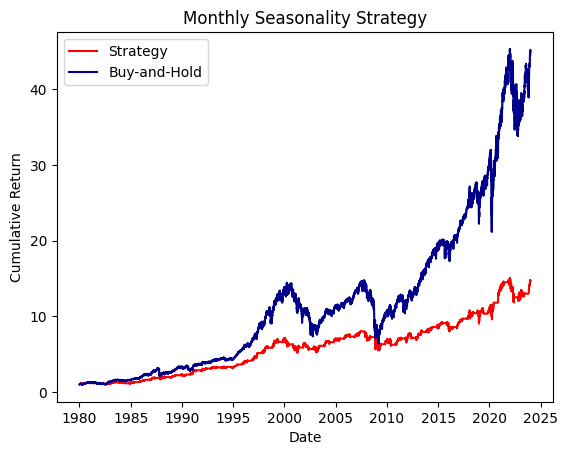

In [413]:
halloween_stra = halloween(trading_daily)
plt.plot(halloween_stra.index, halloween_stra["cum_ret"], color="red")
plt.plot(halloween_stra.index, halloween_stra["buy_hold_ret"], color="darkblue")
plt.title('Monthly Seasonality Strategy')
plt.legend(["Strategy", "Buy-and-Hold"])
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.savefig("Monthly Seasonality Strategy.png")
plt.show()

## Daily Seasonality

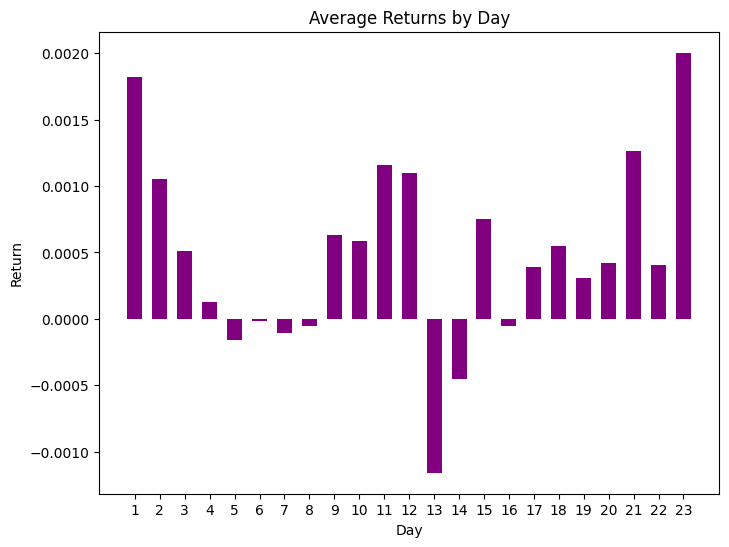

In [414]:
plt.figure(figsize=(8, 6))     
plt.bar(range(1,24), trading_daily.groupby("trading_day").mean()['daily_ret'], 
        width = 0.6, color="purple")
plt.xticks(range(1, 24))
plt.title("Average Returns by Day")
plt.xlabel("Day")
plt.ylabel("Return")
plt.savefig('Average Returns by Day.png')
plt.show()

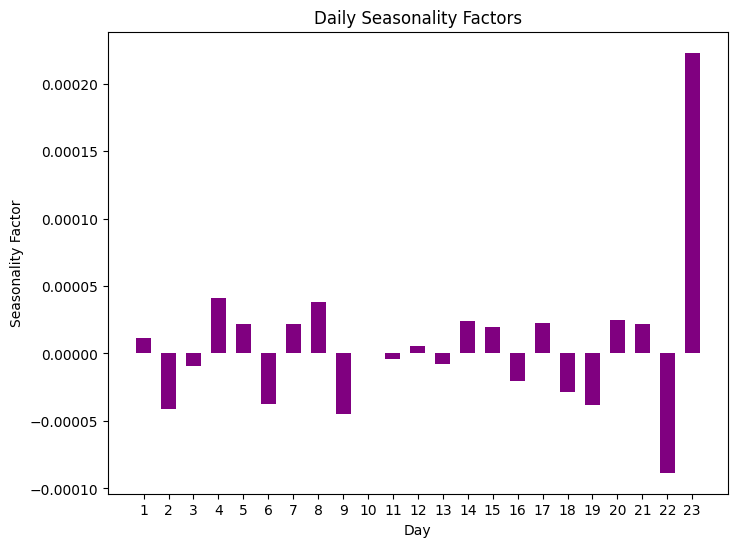

In [415]:
decom = seasonal_decompose(trading_daily["daily_ret"], period=23, two_sided=True)
trend = decom.trend; seasonal = decom.seasonal; residual = decom.resid
temp = trading_daily.copy()
temp["seasonal"] = seasonal

plt.figure(figsize=(8, 6))     
plt.bar(range(1,24), temp.groupby("trading_day")["seasonal"].mean(), 
        width = 0.6, color="purple")
plt.xticks(range(1, 24))
plt.title('Daily Seasonality Factors')
plt.xlabel('Day')
plt.ylabel('Seasonality Factor')
plt.savefig('Seasonality Factor by Day.png')
plt.show()

In [416]:
def hallo_tom(trading_daily, trading_day_long=[1,2,3,19,20,21,22,23], month_long=[1,2,4,5,11,12], starting_year=1980):
    strategy = trading_daily[trading_daily.index.year >= starting_year].copy()
    strategy["position"] = strategy["trading_day"].isin(trading_day_long).astype(int) + trading_daily.index.month.isin(month_long).astype(int)
    strategy["position"] = np.where(strategy["position"]>1.5, 1.5, strategy["position"])
    strategy["pos_change"] = (strategy["position"] - strategy["position"].shift(1)).fillna(1)
    strategy["port_daily_ret"] = strategy["daily_ret"] * strategy["position"] - transac_cost * abs(strategy["pos_change"])
    strategy["cum_ret"] = (1+strategy["port_daily_ret"]).cumprod()
    strategy["buy_hold_ret"] = (1+strategy["daily_ret"]).cumprod()
    return strategy

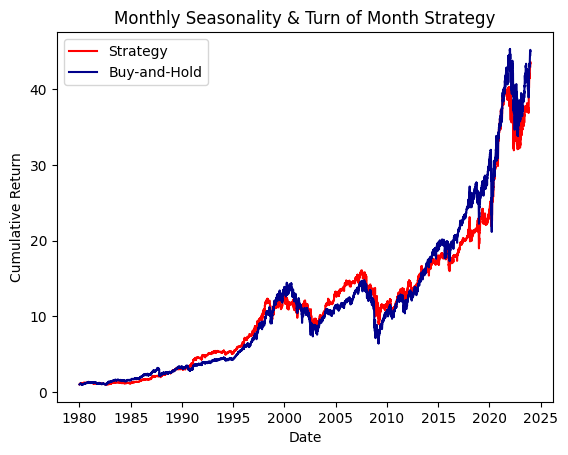

In [417]:
halloween_tom_stra = hallo_tom(trading_daily)
plt.plot(halloween_tom_stra.index, halloween_tom_stra["cum_ret"], color="red")
plt.plot(halloween_tom_stra.index, halloween_tom_stra["buy_hold_ret"], color="darkblue")
plt.title('Monthly Seasonality & Turn of Month Strategy')
plt.legend(["Strategy", "Buy-and-Hold"])
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.savefig("Monthly Seasonality & Turn of Month Strategy.png")
plt.show()

## Jan Barometer

In [418]:
jan_return = monthly[monthly.index.month == 1]; jan_return.index = jan_return.index.year
annual_return = np.log(px.resample("YE").last() / px.resample("YE").first())
annual_return.index = annual_return.index.year
df = pd.concat([jan_return, annual_return], axis=1, join="inner")
df.columns = ["jan_ret", "annual_ret"]

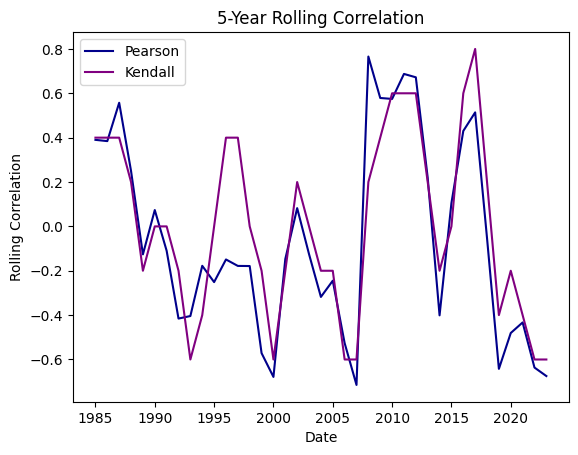

In [419]:
def rolling_kendall_loop(df, window=5):
    arr = df.values
    out = np.full(len(df), np.nan)

    for i in range(window-1, len(arr)):
        a = arr[i-window+1:i+1, 0]
        b = arr[i-window+1:i+1, 1]
        out[i] = kendalltau(a, b)[0]

    return pd.Series(out, index=df.index).dropna()

p_corr = df.rolling(5).corr().unstack().iloc[:,0].dropna()
k_corr = rolling_kendall_loop(df)

plt.plot(p_corr.index, p_corr, color="darkblue")
plt.plot(p_corr.index, k_corr, color="purple")
plt.title("5-Year Rolling Correlation")
plt.xlabel("Date")
plt.ylabel("Rolling Correlation")
plt.legend(["Pearson", "Kendall"])
plt.savefig("Jan Baromter Correlation.png")
plt.show()

In [420]:
print(df[df["jan_ret"]<=0].corr())
print(df[df["jan_ret"]>=0].corr())


             jan_ret  annual_ret
jan_ret     1.000000   -0.438266
annual_ret -0.438266    1.000000
             jan_ret  annual_ret
jan_ret     1.000000   -0.084188
annual_ret -0.084188    1.000000


## Seasonality Weighted Allocation

In [421]:
from sklearn.preprocessing import MinMaxScaler
year_weight = {}
for year in range(monthly.index[0].year+5, monthly.index[-1].year+1):
    data = monthly[(monthly.index.year <= year) & (monthly.index.year > year-5)]
    decom = seasonal_decompose(data, period=12, two_sided=True)
    seasonal = decom.seasonal
    weight= MinMaxScaler(feature_range=(0,2)).fit_transform(seasonal.groupby(seasonal.index.month).mean().values.reshape(-1, 1))
    year_weight[year] = weight.flatten()
weight_df = pd.DataFrame.from_dict(year_weight, orient='index')


def hallo_tom_SW(trading_daily, weight_df, trading_day_long=[1,2,3,19,20,21,22,23], starting_year=1980):
    strategy = trading_daily.copy(); weight_df = weight_df.stack().values
    strategy = trading_daily[trading_daily.index.year >= starting_year].copy()
    strategy["position"] = weight_df[12*(strategy.index.year-1998) + strategy.index.month - 1]
    strategy["position"] = strategy["position"] + strategy["trading_day"].isin(trading_day_long).astype(int)
    strategy["position"] = np.where(strategy["position"]>1.5, 1.5, strategy["position"])
    strategy["pos_change"] = (strategy["position"] - strategy["position"].shift(1)).fillna(1)
    strategy["port_daily_ret"] = strategy["daily_ret"] * strategy["position"] - transac_cost * abs(strategy["pos_change"])
    strategy["cum_ret"] = (1+strategy["port_daily_ret"]).cumprod()
    strategy["buy_hold_ret"] = (1+strategy["daily_ret"]).cumprod()
    return strategy

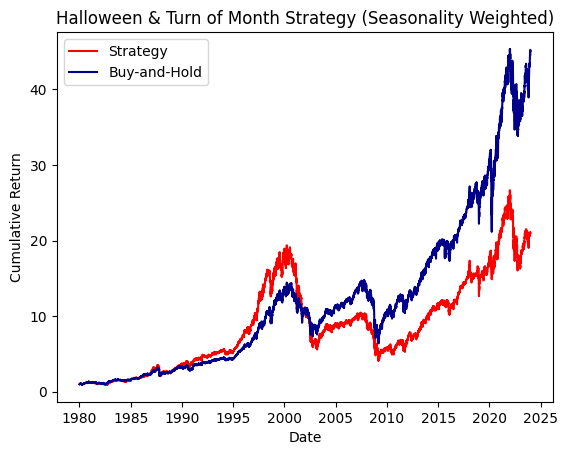

In [422]:
strategy = hallo_tom_SW(trading_daily, weight_df)
plt.plot(strategy.index, strategy["cum_ret"], color="red")
plt.plot(strategy.index, strategy["buy_hold_ret"], color="darkblue")
plt.legend(["Strategy", "Buy-and-Hold"])
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.title("Halloween & Turn of Month Strategy (Seasonality Weighted)")
plt.show()

The results showed that seasonality-based allocation is unprofitable; therefore, this will be excluded from the report.

## Performance

In [423]:
def perf_metrics(daily_ret, rf=0.02):
    n = len(daily_ret)
    cum_ret = (1+daily_ret).cumprod()
    ann_ret = cum_ret.iloc[-1]**(252/n) - 1
    ann_vol = daily_ret.std() * np.sqrt(252)
    sharpe = (ann_ret - rf) / ann_vol
    sortino = (ann_ret - rf) / daily_ret[daily_ret < 0].std()

    peak = cum_ret.cummax()
    drawdown = cum_ret / peak - 1
    max_dd = drawdown.min()

    return ann_ret, ann_vol, sharpe, sortino, max_dd

In [424]:
perf_metrics(halloween_tom_stra["port_daily_ret"])

(np.float64(0.08947496380135456),
 np.float64(0.15269061776518422),
 np.float64(0.4550047987113187),
 np.float64(7.843502638217324),
 np.float64(-0.4418036087151227))

In [425]:
perf_metrics(halloween_stra["port_daily_ret"])

(np.float64(0.0630762587596101),
 np.float64(0.11596019038335187),
 np.float64(0.371474543265276),
 np.float64(5.549544555239785),
 np.float64(-0.3148694636212841))

In [426]:
perf_metrics(halloween_stra["daily_ret"])

(np.float64(0.09038903504451112),
 np.float64(0.1793399973102256),
 np.float64(0.3924893280931129),
 np.float64(7.846636939843493),
 np.float64(-0.5677538774277293))

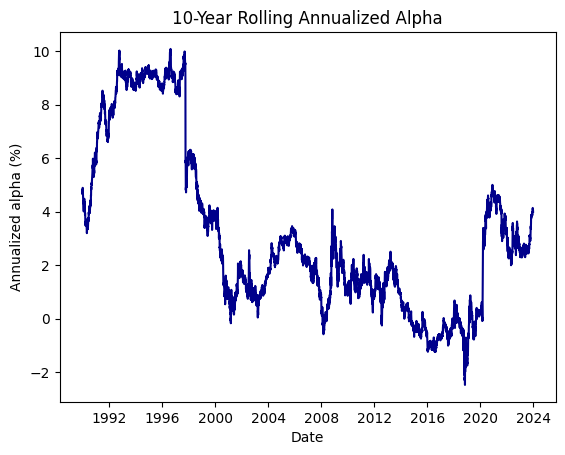

In [427]:
import statsmodels.api as sm
from statsmodels.regression.rolling import RollingOLS

window = 10*252
df = pd.concat([halloween_tom_stra["port_daily_ret"], halloween_tom_stra["daily_ret"]], axis=1).dropna()
df.columns = ["strat", "bench"]
X = sm.add_constant(df["bench"])
rols = RollingOLS(endog=df["strat"], exog=X, window=window)
rres = rols.fit()
alpha = (rres.params["const"] * 252 * 100).dropna()

plt.plot(alpha, color="darkblue")
plt.xlabel('Date')
plt.ylabel('Annualized alpha (%)')
plt.title("10-Year Rolling Annualized Alpha")
plt.savefig("10-Year Rolling Annualized Alpha.png")
plt.show()

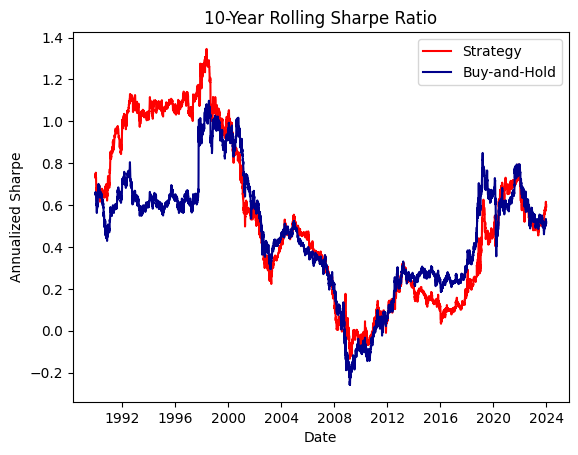

In [428]:
def rolling_sharpe(daily_ret, rf=0.02):
    window = 10*252
    excess = daily_ret - rf / 252
    mu = excess.rolling(window).mean()
    sigma = daily_ret.rolling(window).std()
    sharpe_roll = mu / sigma * np.sqrt(252)
    return sharpe_roll.dropna()

stra_sharpe = rolling_sharpe(halloween_tom_stra["port_daily_ret"])
bench_sharpe = rolling_sharpe(halloween_tom_stra["daily_ret"])

plt.plot(stra_sharpe.index, stra_sharpe, color="red")
plt.plot(stra_sharpe.index, bench_sharpe, color="darkblue")
plt.legend(["Strategy", "Buy-and-Hold"])
plt.xlabel('Date')
plt.ylabel('Annualized Sharpe')
plt.title("10-Year Rolling Sharpe Ratio")
plt.savefig("10-Year Rolling Sharpe Ratio.png")
plt.show()